In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [ ]:
df_raw = pd.read_csv("water_potability.csv")

In [ ]:
df_raw.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
print("Shape:", df_raw.shape)

Shape: (3276, 10)


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df_raw.isna().sum().sort_values(ascending=False)

,0
Sulfate,781
ph,491
Trihalomethanes,162
Hardness,0
Chloramines,0
Solids,0
Conductivity,0
Organic_carbon,0
Turbidity,0
Potability,0


In [ ]:
df_raw.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df = df_raw.copy()

In [ ]:
print("Missing values BEFORE cleaning:")
missing_before = df.isna().sum().sort_values(ascending=False)
display(missing_before[missing_before > 0].to_frame("missing_count"))

Missing values BEFORE cleaning:


,missing_count
Sulfate,781
ph,491
Trihalomethanes,162


In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Dropped duplicates: {before - after}")

Dropped duplicates: 0


In [ ]:
df_before_outliers = df.copy()

In [ ]:
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return lo, hi

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
outlier_check_cols = [c for c in numeric_cols if c != "Potability"]
outlier_mask_any = pd.Series(False, index=df.index)
for c in outlier_check_cols:
    lo, hi = iqr_bounds(df[c].dropna())
    outlier_mask_any |= (df[c] < lo) | (df[c] > hi)

n_outlier_rows = int(outlier_mask_any.sum())
print(f"Outlier rows to remove (any feature outlier): {n_outlier_rows}")

Outlier rows to remove (any feature outlier): 325


In [ ]:
if n_outlier_rows > 0:
    df = df.loc[~outlier_mask_any].copy()
print("\nMissing values AFTER outlier removal:")
missing_after = df.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0].to_frame("missing_count"))


Missing values AFTER outlier removal:


,missing_count
Sulfate,704
ph,451
Trihalomethanes,147


In [ ]:
print("Post-cleaning shape:", df.shape)
df.head()

Post-cleaning shape: (2951, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


,count
Potability,
0,1824
1,1127


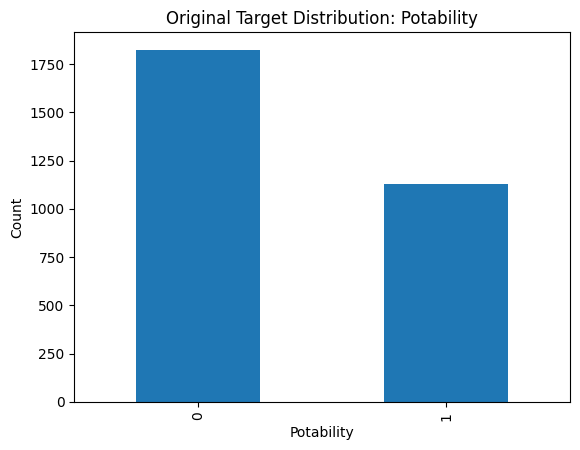

In [ ]:
if "Potability" in df.columns:
    vc = df["Potability"].value_counts(dropna=False)
    display(vc.to_frame("count"))

    ax = vc.sort_index().plot(kind="bar")
    ax.set_title("Original Target Distribution: Potability")
    ax.set_xlabel("Potability")
    ax.set_ylabel("Count")
    plt.show()
else:
    print("Column 'Potability' not found. Check dataset columns:", df.columns.tolist())

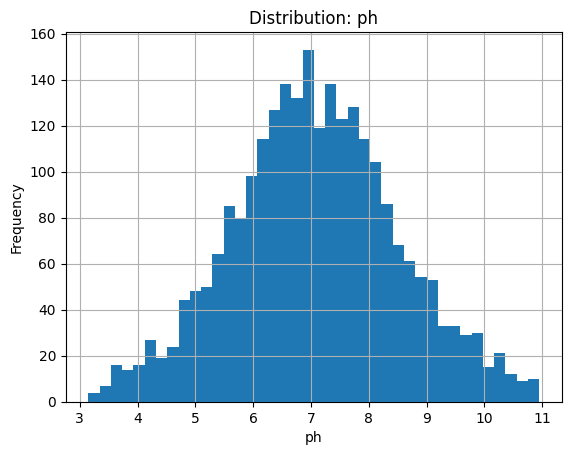

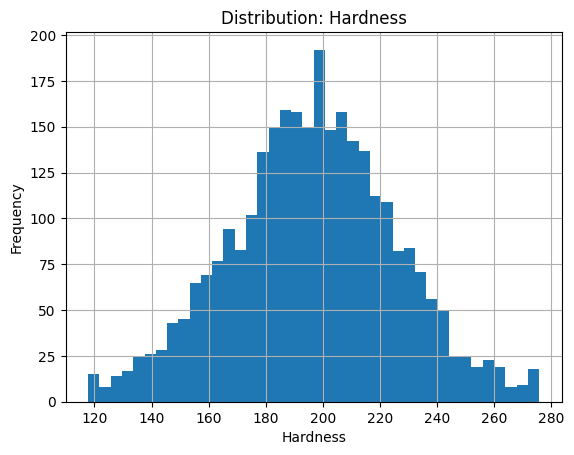

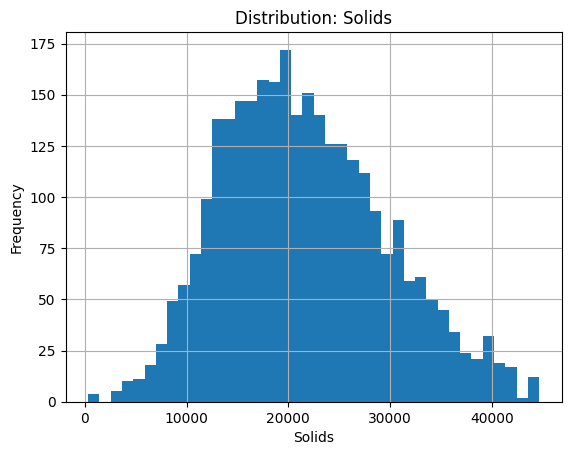

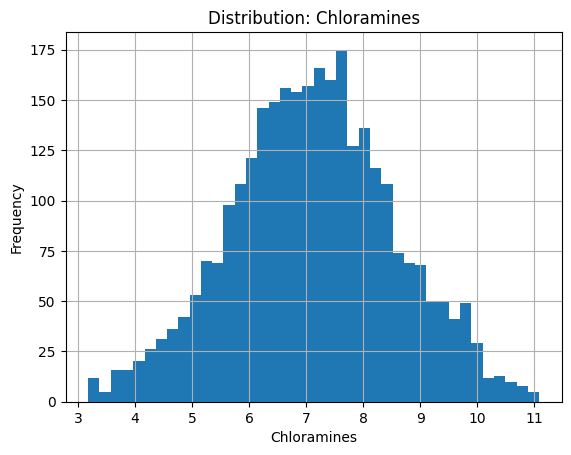

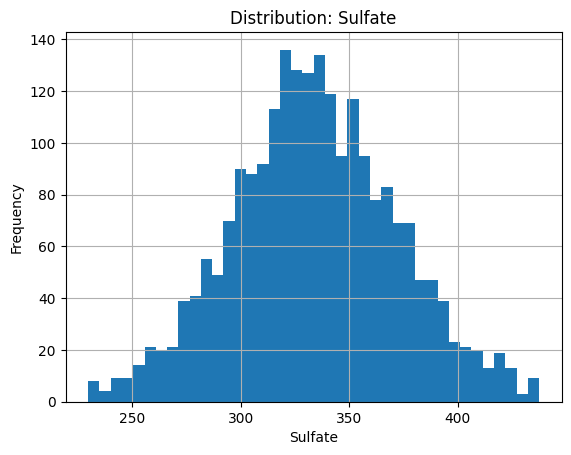

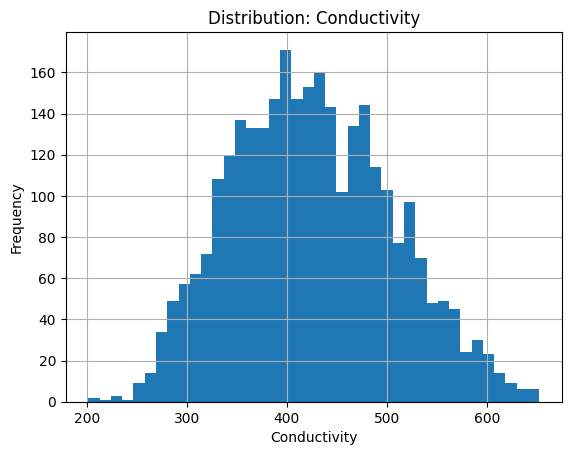

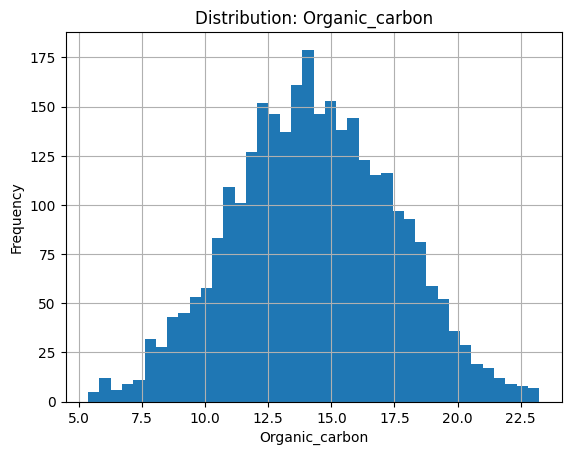

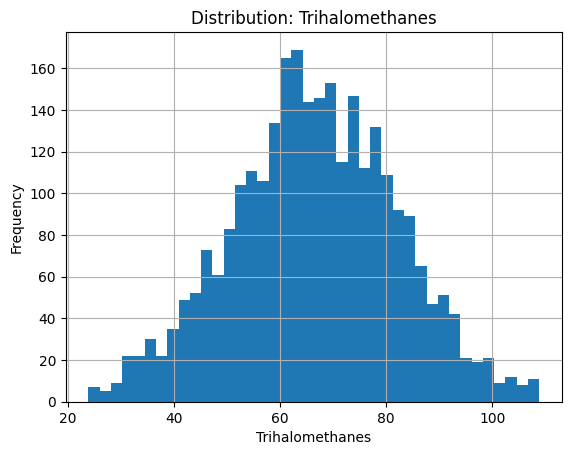

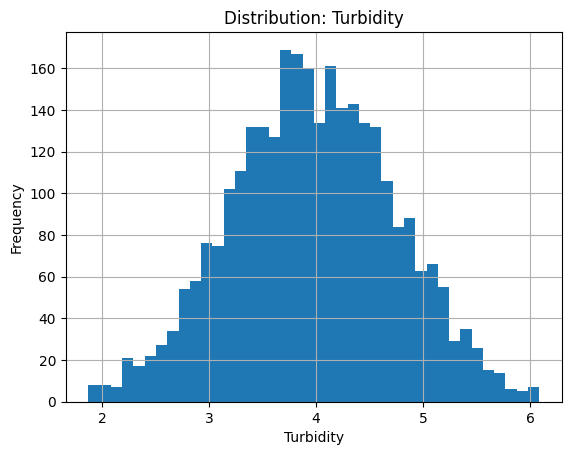

In [ ]:
num_no_target = [c for c in numeric_cols if c != "Potability"]
for c in num_no_target:
    ax = df[c].hist(bins=40)
    ax.set_title(f"Distribution: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Frequency")
    plt.show()

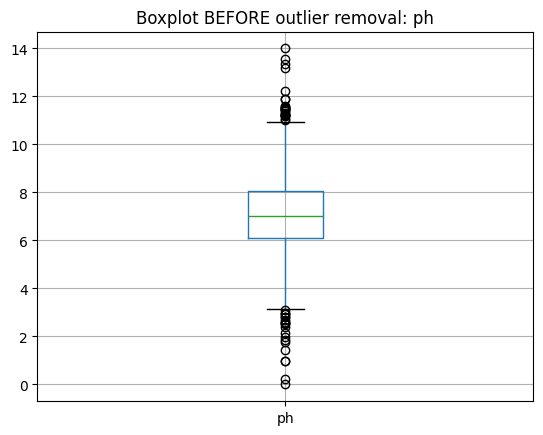

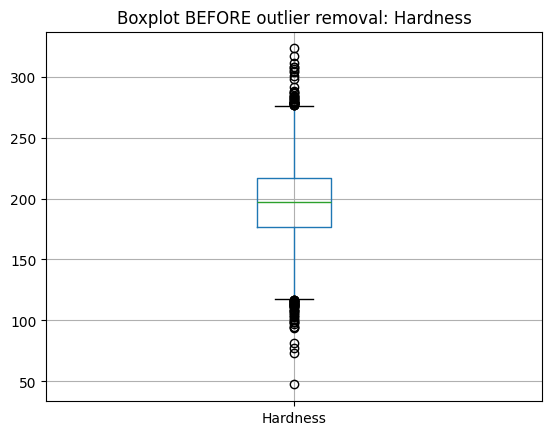

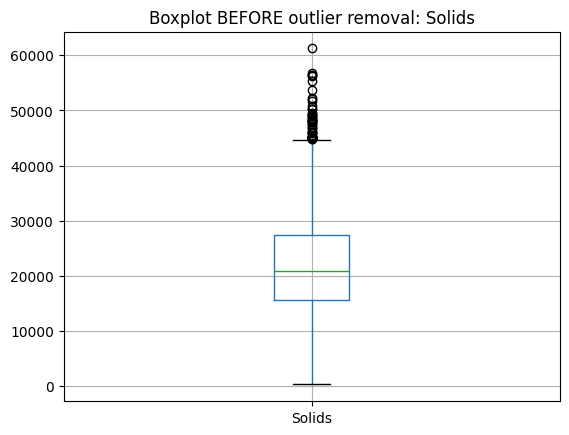

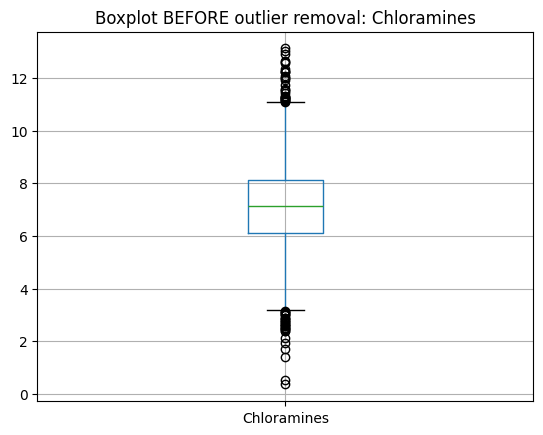

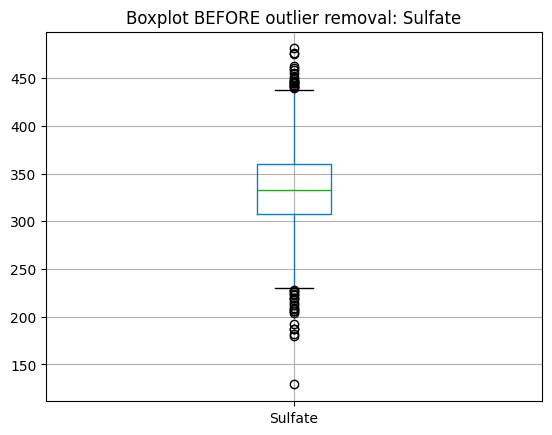

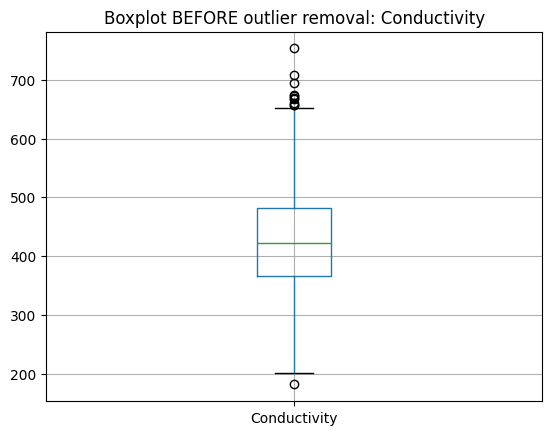

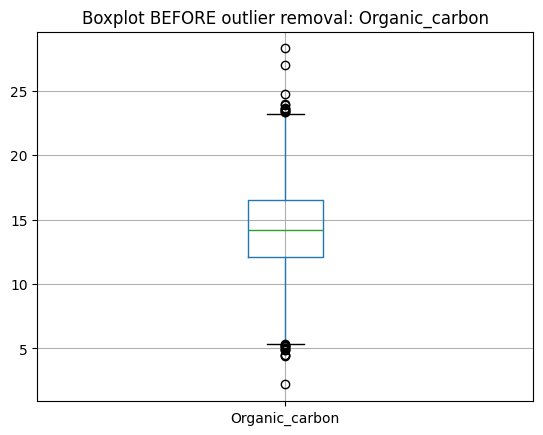

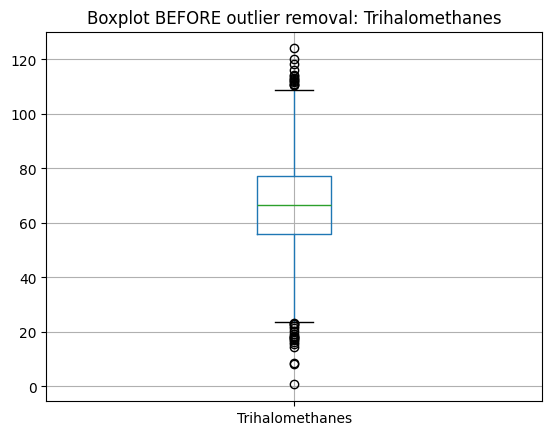

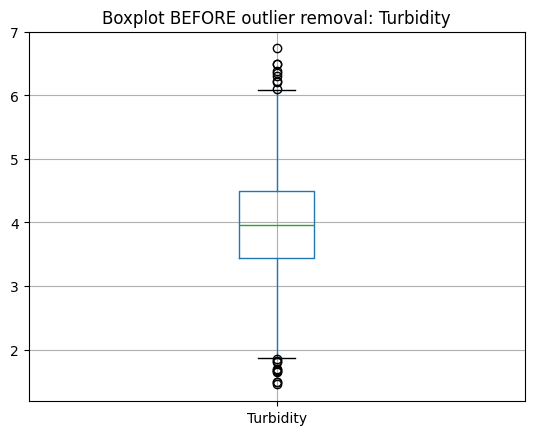

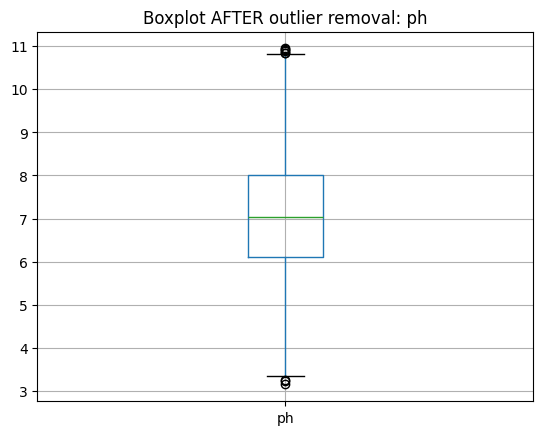

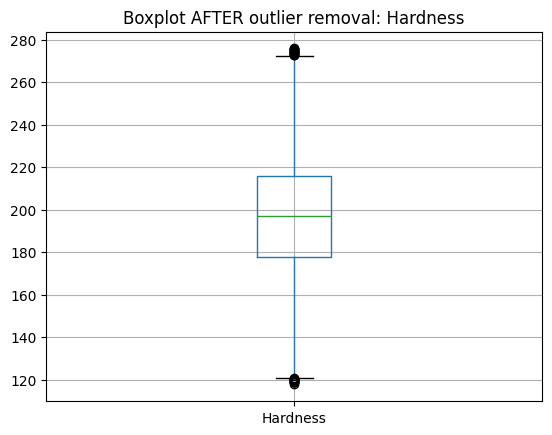

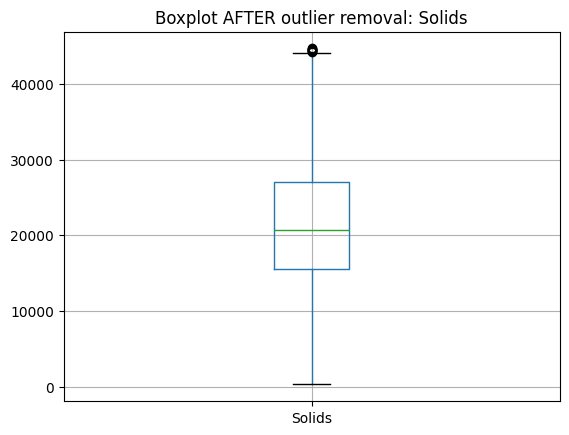

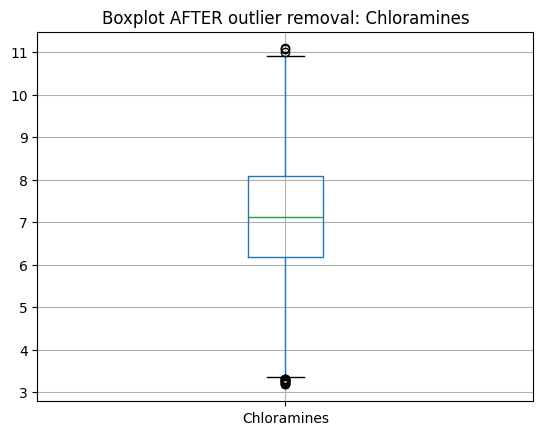

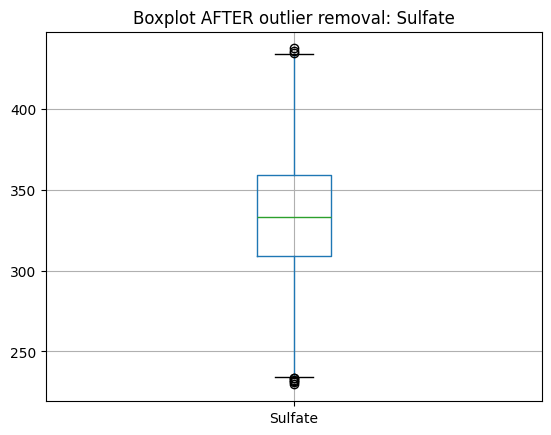

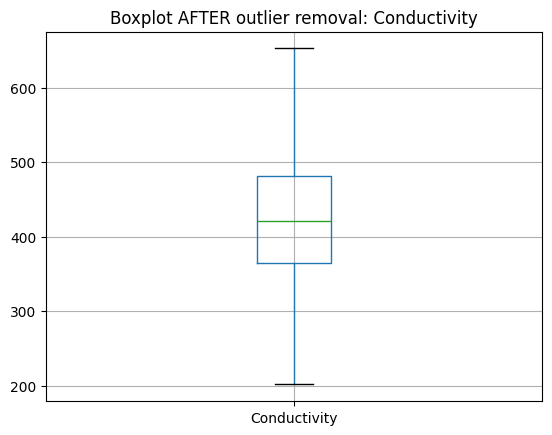

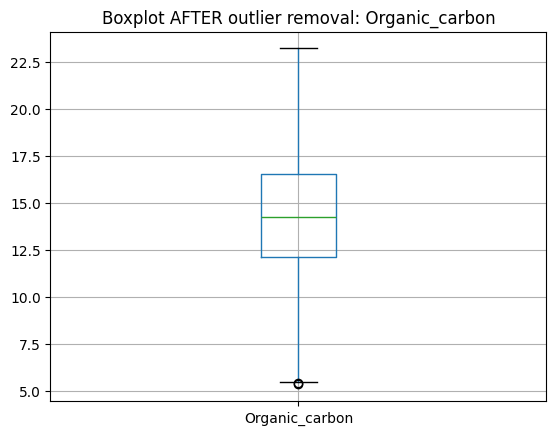

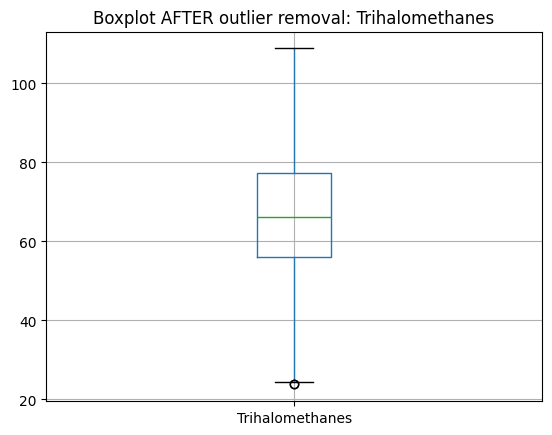

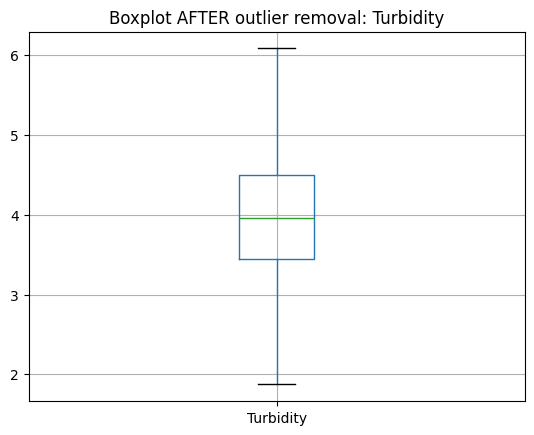

In [ ]:
for c in num_no_target:
    ax = df_before_outliers[[c]].boxplot()
    ax.set_title(f"Boxplot BEFORE outlier removal: {c}")
    plt.show()

# Boxplots AFTER outlier removal
for c in num_no_target:
    ax = df[[c]].boxplot()
    ax.set_title(f"Boxplot AFTER outlier removal: {c}")
    plt.show()

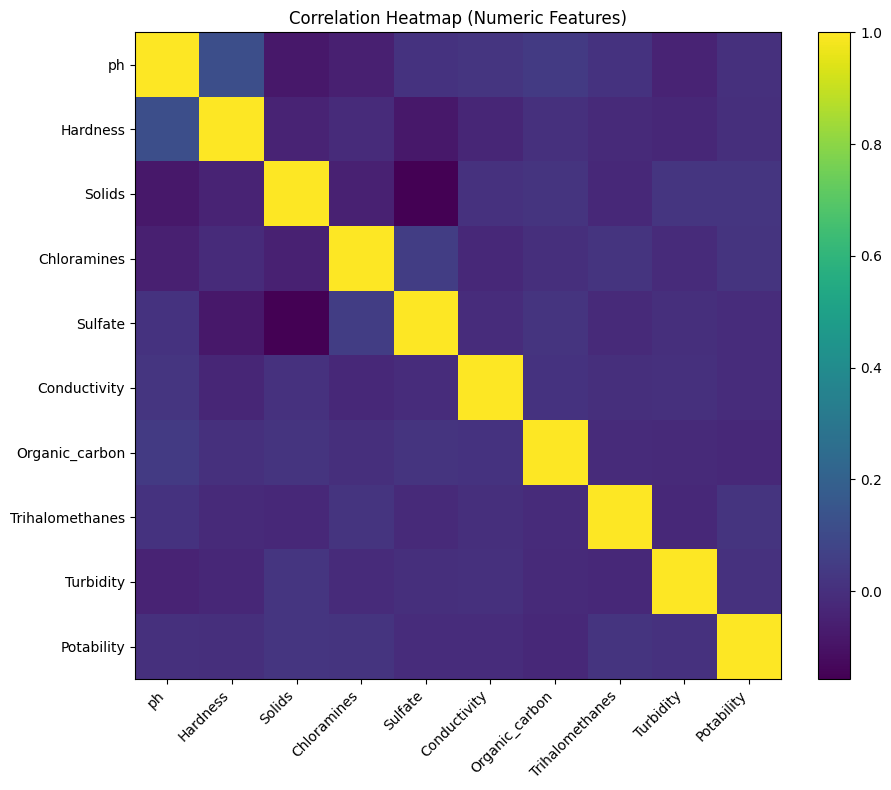

,abs_corr_with_potability
Organic_carbon,0.023978
Solids,0.021796
Chloramines,0.018630
Trihalomethanes,0.015368
Conductivity,0.010440
Sulfate,0.008297
Turbidity,0.007440
ph,0.003850
Hardness,0.002571


In [ ]:
corr = df[num_no_target + (["Potability"] if "Potability" in df.columns else [])].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

if "Potability" in corr.columns:
    top = corr["Potability"].drop("Potability").abs().sort_values(ascending=False)
    display(top.head(10).to_frame("abs_corr_with_potability"))

In [ ]:
print("Summary statistics AFTER cleaning:")
display(df.describe(include="all").T)


Summary statistics AFTER cleaning:


,count,mean,std,min,25%,50%,75%,max
ph,2500.0,7.073836,1.443743,3.148712,6.115523,7.035894,8.001340,10.947473
Hardness,2951.0,196.509523,29.295255,117.791230,177.837686,197.191839,215.737874,275.886513
Solids,2951.0,21597.987516,8080.717798,320.942611,15521.392543,20743.348404,26981.849628,44652.363872
Chloramines,2951.0,7.118711,1.437921,3.181183,6.175305,7.121477,8.076082,11.086526
Sulfate,2247.0,334.105192,37.901251,229.575561,309.080461,333.289216,359.134227,437.647163
Conductivity,2951.0,425.545964,80.117872,201.619737,365.210558,421.183478,481.330288,652.537592
Organic_carbon,2951.0,14.317080,3.206064,5.362371,12.127810,14.243374,16.576383,23.234326
Trihalomethanes,2804.0,66.419854,15.573778,23.792950,55.939855,66.300896,77.324282,108.849568
Turbidity,2951.0,3.969211,0.760715,1.872573,3.440526,3.954964,4.498444,6.083772
Potability,2951.0,0.381904,0.485936,0.000000,0.000000,0.000000,1.000000,1.000000


In [ ]:

eda_notes = {
    "rows_before": int(df_raw.shape[0]),
    "rows_after_cleaning": int(df.shape[0]),
    "cols": int(df.shape[1]),
    "missing_total_after": int(df.isna().sum().sum()),
    "duplicates_removed": int(df_raw.duplicated().sum()),
}

display(pd.DataFrame([eda_notes]))

,rows_before,rows_after_cleaning,cols,missing_total_after,duplicates_removed
0,3276,2951,10,1302,0


In [ ]:
if "Potability" in df.columns:
    display(df["Potability"].value_counts(normalize=True).to_frame("proportion"))

,proportion
Potability,
0,0.618096
1,0.381904


In [ ]:
features_for_index = [c for c in num_no_target if c != "Potability"]

X_index = df[features_for_index].copy()

X_index = X_index.fillna(X_index.median(numeric_only=True))

In [ ]:
Z = (X_index - X_index.mean()) / X_index.std(ddof=0)
quality_index = Z.mean(axis=1)

df["quality_index"] = quality_index

labels = ["Q1_low", "Q2_mid", "Q3_mid", "Q4_high"]
df["QualityClass"] = pd.qcut(df["quality_index"], q=4, labels=labels)

display(df[["quality_index", "QualityClass"]].head())

,quality_index,QualityClass
0,0.207977,Q3_mid
1,-0.349236,Q1_low
2,0.278261,Q4_high
3,0.728994,Q4_high
4,-0.432785,Q1_low


In [ ]:
vc = df["QualityClass"].value_counts().sort_index()
display(vc.to_frame("count"))

,count
QualityClass,
Q1_low,738
Q2_mid,738
Q3_mid,737
Q4_high,738


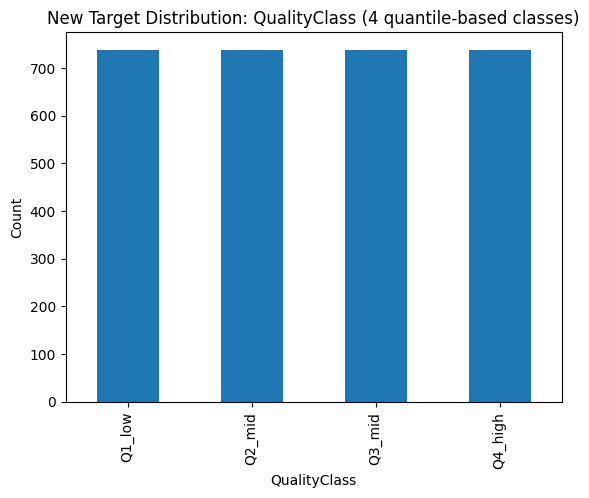

In [ ]:
ax = vc.plot(kind="bar")
ax.set_title("New Target Distribution: QualityClass (4 quantile-based classes)")
ax.set_xlabel("QualityClass")
ax.set_ylabel("Count")
plt.show()

In [ ]:
df_fe = df.copy()


# Example interaction/composite features
# Ratios are stabilized with a small epsilon.
eps = 1e-9
if set(["Hardness", "Solids"]).issubset(df_fe.columns):
    df_fe["Hardness_to_Solids"] = df_fe["Hardness"] / (df_fe["Solids"] + eps)

if set(["Sulfate", "Conductivity"]).issubset(df_fe.columns):
    df_fe["Sulfate_to_Conductivity"] = df_fe["Sulfate"] / (df_fe["Conductivity"] + eps)

if set(["ph", "Turbidity"]).issubset(df_fe.columns):
    df_fe["ph_x_Turbidity"] = df_fe["ph"] * df_fe["Turbidity"]

# Quartile bins become categorical and are one-hot encoded later
for c in ["ph", "Turbidity", "Solids"]:
    if c in df_fe.columns:
        df_fe[f"{c}_bin"] = pd.qcut(df_fe[c].fillna(df_fe[c].median()), q=4, labels=["bin1", "bin2", "bin3", "bin4"])


# Drop helper numeric index to avoid leakage (target derived from it)
df_fe = df_fe.drop(columns=["quality_index"])

print("Feature-engineered shape:", df_fe.shape)

Feature-engineered shape: (2951, 17)


In [ ]:
df_fe.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,QualityClass,Hardness_to_Solids,Sulfate_to_Conductivity,ph_x_Turbidity,ph_bin,Turbidity_bin,Solids_bin
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,Q3_mid,0.009855,0.653041,NaN,1,0,2
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0,Q1_low,0.006947,NaN,16.724799,0,3,1
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0,Q4_high,0.011263,NaN,24.750387,3,0,1
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,Q4_high,0.009736,0.982436,38.496401,3,3,2
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,Q1_low,0.010073,0.778432,37.051496,3,2,1


In [ ]:
y = df['Potability']

features_to_drop = ['Potability', 'QualityClass']
X = df.drop(columns=features_to_drop)

In [ ]:
# Simple median imputation
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['ph_bin', 'Turbidity_bin', 'Solids_bin']:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

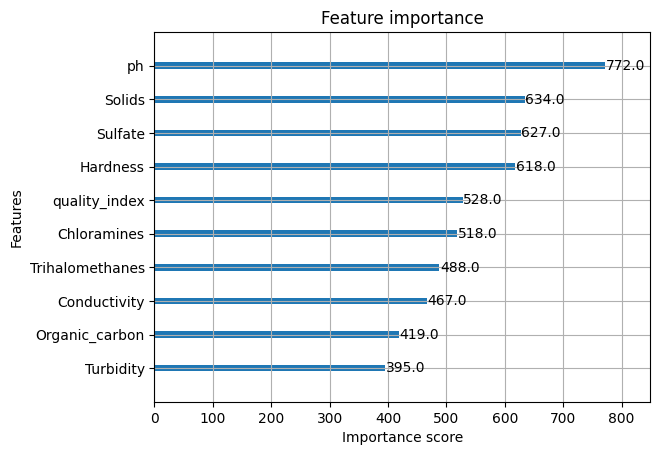

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.show()

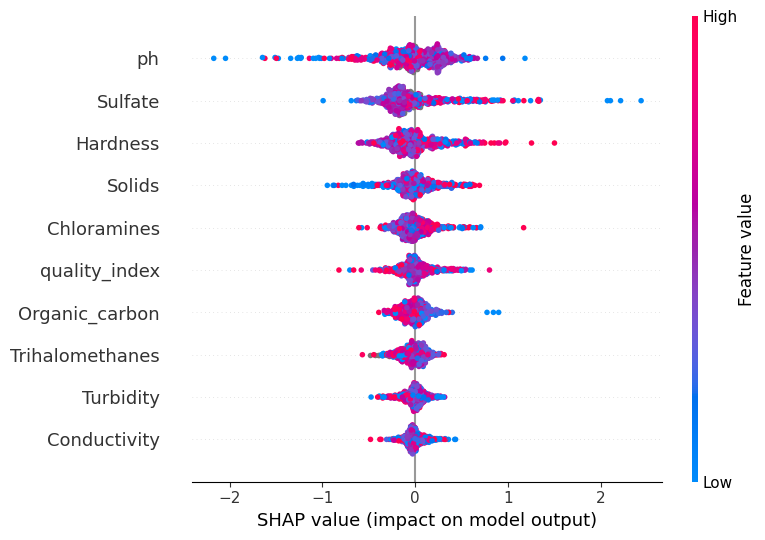

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       365
           1       0.57      0.31      0.40       226

    accuracy                           0.65       591
   macro avg       0.62      0.58      0.57       591
weighted avg       0.63      0.65      0.62       591



In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
# Impute missing values in X_train before applying SMOTE
X_train_imputed = X_train.copy()
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    if col in X_train_imputed.columns:
        X_train_imputed[col] = X_train_imputed[col].fillna(X_train_imputed[col].median())

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imputed, y_train)

In [ ]:
model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05)
model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.62      0.66       365
           1       0.48      0.58      0.53       226

    accuracy                           0.60       591
   macro avg       0.59      0.60      0.59       591
weighted avg       0.62      0.60      0.61       591



In [ ]:
refined_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    gamma=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

refined_model.fit(X_train_balanced, y_train_balanced)
print(classification_report(y_test, refined_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.70      0.61      0.65       365
           1       0.47      0.57      0.52       226

    accuracy                           0.59       591
   macro avg       0.59      0.59      0.58       591
weighted avg       0.61      0.59      0.60       591



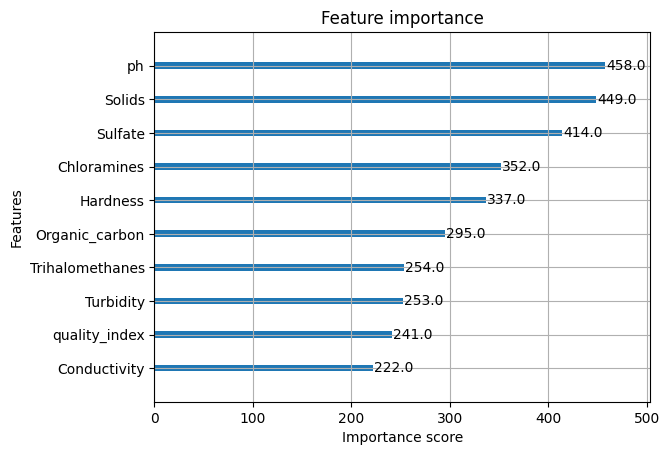

In [ ]:
plot_importance(refined_model, max_num_features=10)
plt.show()

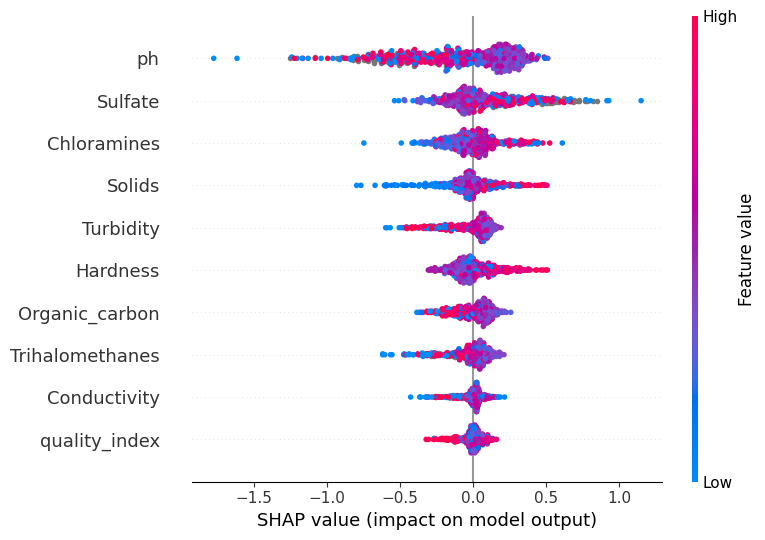

In [ ]:
explainer = shap.TreeExplainer(refined_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
import joblib

# 1. Save the XGBoost Model
joblib.dump(refined_model, 'water_model.pkl')

train_medians = X_train_imputed.median().to_dict()
joblib.dump(train_medians, 'train_medians.pkl')

# 3. Save the Feature Names
joblib.dump(list(X_train_imputed.columns), 'features.pkl')

print("Files saved successfully!")

Files saved successfully!
